# Notebook 07 — Weekly Horizon (5-day direction)

**Purpose:** Test whether predicting direction over a 5-day (weekly) horizon
is easier than the 1-day horizon used in NB05/06.

## Why this might help
- Daily returns ≈ white noise (NB02). Averaging over 5 days smooths noise,
  so the underlying trend may be more learnable.
- Weekly/monthly features (COT, macro) match this rhythm better.

## What changes vs NB05/06
- **ONLY the target changes:** direction of `eurusd[t+5]` vs `eurusd[t]`
  (does price go up or down over the next 5 trading days?)
- Everything else identical: same 31 features, same 70/20/10 chronological
  split, same models, same evaluation — for a fair daily-vs-weekly comparison.

## New leakage guard
- Because the target looks 5 days ahead, overlapping windows near the
  train/val/test boundaries would leak. We insert a **5-day embargo gap**
  at each boundary.

---
**Author:** Đồng Công Gia Khang · **Date:** June 2026

## 1. Setup

In [2]:
"""
Setup: imports, paths, device.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def find_project_root(marker=".env"):
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 5   # predict direction 5 trading days ahead

print(f"Device: {device}")
print(f"Horizon: {HORIZON} trading days")
print(f"Project: {PROJECT_ROOT}")

Device: cuda
Horizon: 5 trading days
Project: c:\Users\Khang\Desktop\Final Project 2


## 2. Load Features + Build Weekly Target

- Reuse the 31 features from `fx_features.csv` (unchanged).
- Rebuild the target from the raw EUR/USD price in the master dataset:
  `target_weekly = 1 if eurusd[t+HORIZON] > eurusd[t] else 0`.
- Drop the last HORIZON rows (no future price to compare against).

In [3]:
"""
Load features, attach raw price, build 5-day-ahead direction target.
"""
# 1) Feature set (already engineered)
feat = pd.read_csv(PROCESSED_DIR / "fx_features.csv", parse_dates=["date"])
feature_cols = [c for c in feat.columns
                if c not in ["date", "target_return_next_day", "target_direction"]]

# 2) Raw EUR/USD price from master dataset
master = pd.read_csv(PROJECT_ROOT / "data" / "interim" / "fx_master_dataset.csv",
                     parse_dates=["date"])[["date", "eurusd"]]

# 3) Align on date (keep only rows present in features)
df = feat.merge(master, on="date", how="left").sort_values("date").reset_index(drop=True)
print(f"Merged: {df.shape}, missing price: {df['eurusd'].isna().sum()}")

# 4) Weekly target: price HORIZON days ahead vs today
df["future_price"] = df["eurusd"].shift(-HORIZON)
df["target_weekly"] = (df["future_price"] > df["eurusd"]).astype(int)

# 5) Drop last HORIZON rows (no future price)
df = df.iloc[:-HORIZON].reset_index(drop=True)

print(f"After dropping last {HORIZON} rows: {df.shape}")
print(f"\nWeekly target balance:")
print(f"  UP:   {df['target_weekly'].mean()*100:.2f}%")
print(f"  DOWN: {(1-df['target_weekly'].mean())*100:.2f}%")
print(f"\nCompare — daily target balance was ~49% UP / 51% DOWN")

Merged: (4084, 35), missing price: 0
After dropping last 5 rows: (4079, 37)

Weekly target balance:
  UP:   49.11%
  DOWN: 50.89%

Compare — daily target balance was ~49% UP / 51% DOWN


## 3. Chronological Split 70/20/10 + Embargo Gap

Same 70/20/10 split as NB05/06, but with a **HORIZON-day embargo** removed
at each boundary. Without it, the weekly target of the last training rows
would peek into the validation period (label leakage across the boundary).

In [4]:
"""
70/20/10 split with an embargo gap at each boundary.
"""
n = len(df)
i70, i90 = int(n * 0.70), int(n * 0.90)

# Embargo: drop HORIZON rows right BEFORE each boundary
train_df = df.iloc[:i70 - HORIZON].reset_index(drop=True)
val_df   = df.iloc[i70:i90 - HORIZON].reset_index(drop=True)
test_df  = df.iloc[i90:].reset_index(drop=True)

print("SPLIT WITH EMBARGO (weekly target)")
print("=" * 64)
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:5s}: {len(d):5d} rows  "
          f"{d['date'].min().date()} -> {d['date'].max().date()}  "
          f"UP {d['target_weekly'].mean()*100:.2f}%")
print("=" * 64)

# Baselines (majority class) per split
VAL_BASE  = max(val_df['target_weekly'].mean(),  1 - val_df['target_weekly'].mean())
TEST_BASE = max(test_df['target_weekly'].mean(), 1 - test_df['target_weekly'].mean())
print(f"Val baseline:  {VAL_BASE*100:.2f}%")
print(f"Test baseline: {TEST_BASE*100:.2f}%")

# Prepare X / y
X_train, y_train = train_df[feature_cols].values, train_df["target_weekly"].values
X_val,   y_val   = val_df[feature_cols].values,   val_df["target_weekly"].values
X_test,  y_test  = test_df[feature_cols].values,  test_df["target_weekly"].values
print(f"\nFeatures: {len(feature_cols)} | Train X: {X_train.shape}")

SPLIT WITH EMBARGO (weekly target)
Train:  2850 rows  2010-02-02 -> 2021-06-11  UP 49.12%
Val  :   811 rows  2021-06-21 -> 2024-09-10  UP 48.21%
Test :   408 rows  2024-09-18 -> 2026-05-05  UP 50.49%
Val baseline:  51.79%
Test baseline: 50.49%

Features: 31 | Train X: (2850, 31)


## 4. Train ML Models (weekly target)

Same 3 models and hyperparameters as NB05, only the target changed.
This isolates the effect of horizon (daily vs weekly).

In [5]:
"""
Train RF / XGBoost / LightGBM on the weekly target.
"""
results = {}

def evaluate(name, model):
    tr = accuracy_score(y_train, model.predict(X_train))
    va = accuracy_score(y_val,   model.predict(X_val))
    te = accuracy_score(y_test,  model.predict(X_test))
    results[name] = {"train": tr, "val": va, "test": te}
    print(f"=== {name} ===")
    print(f"Train: {tr*100:5.2f}%")
    print(f"Val:   {va*100:5.2f}%   vs baseline {VAL_BASE*100:.2f}%  ({(va-VAL_BASE)*100:+.2f} pp)")
    print(f"Test:  {te*100:5.2f}%   vs baseline {TEST_BASE*100:.2f}%  ({(te-TEST_BASE)*100:+.2f} pp)")

rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=20,
    random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf)

xgb = XGBClassifier(
    n_estimators=400, max_depth=3, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
    reg_lambda=2.0, eval_metric="logloss", random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
evaluate("XGBoost", xgb)

lgbm = LGBMClassifier(
    n_estimators=400, max_depth=3, num_leaves=7, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_lambda=2.0, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
evaluate("LightGBM", lgbm)

=== Random Forest ===
Train: 76.91%
Val:   49.32%   vs baseline 51.79%  (-2.47 pp)
Test:  50.98%   vs baseline 50.49%  (+0.49 pp)
=== XGBoost ===
Train: 79.16%
Val:   48.09%   vs baseline 51.79%  (-3.70 pp)
Test:  52.45%   vs baseline 50.49%  (+1.96 pp)
=== LightGBM ===
Train: 79.40%
Val:   47.35%   vs baseline 51.79%  (-4.44 pp)
Test:  50.74%   vs baseline 50.49%  (+0.25 pp)


## 5. Deep Learning on Weekly Target (LSTM & GRU)

ML (tree-based) didn't benefit from the weekly horizon — likely because the
features describe short-term (daily) dynamics that don't align with a 5-day
target. RNNs read a 10-day sequence, so they may bridge this gap better.
Scaling fit on train only; windows built per split (no leakage).

In [6]:
"""
Scale + window + define RNN (same architecture as NB06).
"""
WINDOW = 10

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xva_s = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)

def make_windows(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i]); ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

Xtr_w, ytr_w = make_windows(Xtr_s, y_train, WINDOW)
Xva_w, yva_w = make_windows(Xva_s, y_val,   WINDOW)
Xte_w, yte_w = make_windows(Xte_s, y_test,  WINDOW)

print(f"Train windows: {Xtr_w.shape}")
print(f"Val   windows: {Xva_w.shape}")
print(f"Test  windows: {Xte_w.shape}")

VAL_BASE_W  = max(yva_w.mean(),  1 - yva_w.mean())
TEST_BASE_W = max(yte_w.mean(),  1 - yte_w.mean())
print(f"Val baseline:  {VAL_BASE_W*100:.2f}%")
print(f"Test baseline: {TEST_BASE_W*100:.2f}%")


class RNNClassifier(nn.Module):
    def __init__(self, n_features, hidden=32, dropout=0.3, rnn_type="LSTM"):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(n_features, hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden, 16), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(16, 1))
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1, :]).squeeze(-1)

n_features = Xtr_w.shape[2]
print(f"\nRNN ready. n_features = {n_features}")

Train windows: (2840, 10, 31)
Val   windows: (801, 10, 31)
Test  windows: (398, 10, 31)
Val baseline:  51.56%
Test baseline: 50.75%

RNN ready. n_features = 31


## 6. Train & Evaluate RNNs (weekly)

In [7]:
"""
Train LSTM & GRU on weekly target, early stopping on validation.
"""
train_loader = DataLoader(
    TensorDataset(torch.tensor(Xtr_w), torch.tensor(ytr_w)),
    batch_size=64, shuffle=True)

Xva_t = torch.tensor(Xva_w).to(device)
Xte_t = torch.tensor(Xte_w).to(device)
Xtr_t = torch.tensor(Xtr_w).to(device)

@torch.no_grad()
def predict(model, X_t):
    model.eval()
    return (torch.sigmoid(model(X_t)) >= 0.5).long().cpu().numpy()

def train_rnn(rnn_type, epochs=80, lr=1e-3, weight_decay=1e-4, patience=12):
    torch.manual_seed(SEED)
    model = RNNClassifier(n_features, rnn_type=rnn_type).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()
    best_val, best_state, wait = 0.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        va = accuracy_score(yva_w, predict(model, Xva_t))
        if va > best_val:
            best_val, best_state, wait = va, \
                {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    print(f"{rnn_type}: best val = {best_val*100:.2f}% (epoch {ep})")
    return model

def full_eval(name, model):
    tr = accuracy_score(ytr_w, predict(model, Xtr_t))
    va = accuracy_score(yva_w, predict(model, Xva_t))
    te = accuracy_score(yte_w, predict(model, Xte_t))
    results[name] = {"train": tr, "val": va, "test": te}
    print(f"=== {name} ===")
    print(f"Train: {tr*100:5.2f}%")
    print(f"Val:   {va*100:5.2f}%   vs baseline {VAL_BASE_W*100:.2f}%  ({(va-VAL_BASE_W)*100:+.2f} pp)")
    print(f"Test:  {te*100:5.2f}%   vs baseline {TEST_BASE_W*100:.2f}%  ({(te-TEST_BASE_W)*100:+.2f} pp)")

lstm = train_rnn("LSTM")
gru  = train_rnn("GRU")
print()
full_eval("LSTM", lstm)
full_eval("GRU",  gru)

LSTM: best val = 51.81% (epoch 16)
GRU: best val = 54.06% (epoch 13)

=== LSTM ===
Train: 57.43%
Val:   51.81%   vs baseline 51.56%  (+0.25 pp)
Test:  53.52%   vs baseline 50.75%  (+2.76 pp)
=== GRU ===
Train: 52.11%
Val:   54.06%   vs baseline 51.56%  (+2.50 pp)
Test:  50.25%   vs baseline 50.75%  (-0.50 pp)


## 7. Summary — Daily vs Weekly, All Models

In [8]:
"""
Weekly results table + save, and print daily-vs-weekly comparison.
"""
import joblib

weekly = pd.DataFrame(results).T * 100
weekly = weekly[["train", "val", "test"]].round(2)
weekly["val_vs_base"] = (weekly["val"] - VAL_BASE*100).round(2)
print("WEEKLY HORIZON (5-day) — all models")
print("=" * 60)
print(weekly.to_string())
print(f"\nWeekly val baseline: {VAL_BASE*100:.2f}%")

# Save weekly models + results
joblib.dump(rf,   MODELS_DIR / "weekly_random_forest.pkl")
joblib.dump(xgb,  MODELS_DIR / "weekly_xgboost.pkl")
joblib.dump(lgbm, MODELS_DIR / "weekly_lightgbm.pkl")
torch.save(lstm.state_dict(), MODELS_DIR / "weekly_lstm.pt")
torch.save(gru.state_dict(),  MODELS_DIR / "weekly_gru.pt")
weekly.to_csv(MODELS_DIR / "weekly_results.csv")
print("Saved weekly models + weekly_results.csv")

# Best model by validation
best = weekly["val"].idxmax()
print(f"\nBest weekly model (by val): {best} = {weekly.loc[best,'val']:.2f}% "
      f"(+{weekly.loc[best,'val']-VAL_BASE*100:.2f} pp over baseline)")

WEEKLY HORIZON (5-day) — all models
               train    val   test  val_vs_base
Random Forest  76.91  49.32  50.98        -2.47
XGBoost        79.16  48.09  52.45        -3.70
LightGBM       79.40  47.35  50.74        -4.44
LSTM           57.43  51.81  53.52         0.02
GRU            52.11  54.06  50.25         2.27

Weekly val baseline: 51.79%
Saved weekly models + weekly_results.csv

Best weekly model (by val): GRU = 54.06% (+2.27 pp over baseline)


## 8. Final Comparison — Daily vs Weekly, All 10 Models

In [9]:
"""
Combine daily (NB06) + weekly results into one comparison table + chart.
"""
# --- Load daily results saved by NB06 ---
daily_path = MODELS_DIR / "all_models_results.csv"
daily = pd.read_csv(daily_path, index_col=0)
daily.columns = [c.strip().lower().replace(" %", "").replace(" ", "_") for c in daily.columns]
daily = daily[["train", "val", "test"]].copy()

# weekly results are already in `weekly` (from Cell 15)
wk = weekly[["train", "val", "test"]].copy()

# --- Build combined table with horizon label ---
daily.index = [f"{m} (D)" for m in daily.index]
wk.index    = [f"{m} (W)" for m in wk.index]
combined = pd.concat([daily, wk])
combined = combined.sort_values("val", ascending=False).round(2)

print("=" * 66)
print("ALL 10 MODELS — ranked by Validation accuracy")
print("(D) = Daily horizon   (W) = Weekly horizon")
print("=" * 66)
print(combined.to_string())
print("=" * 66)
print(f"Daily val baseline ~50.6%  |  Weekly val baseline ~51.8%")
print(f"\nBest overall (by val): {combined['val'].idxmax()} = {combined['val'].max():.2f}%")

combined.to_csv(MODELS_DIR / "all_10_models_comparison.csv")
print("Saved all_10_models_comparison.csv")

ALL 10 MODELS — ranked by Validation accuracy
(D) = Daily horizon   (W) = Weekly horizon
                   train    val   test
GRU (W)            52.11  54.06  50.25
LSTM (D)           54.49  53.78  47.37
GRU (D)            53.41  53.41  52.13
LightGBM (D)       78.31  51.90  45.72
LSTM (W)           57.43  51.81  53.52
Random Forest (D)  75.89  51.53  47.92
XGBoost (D)        76.24  50.43  44.01
Random Forest (W)  76.91  49.32  50.98
XGBoost (W)        79.16  48.09  52.45
LightGBM (W)       79.40  47.35  50.74
Daily val baseline ~50.6%  |  Weekly val baseline ~51.8%

Best overall (by val): GRU (W) = 54.06%
Saved all_10_models_comparison.csv


## 9. Comparison Chart

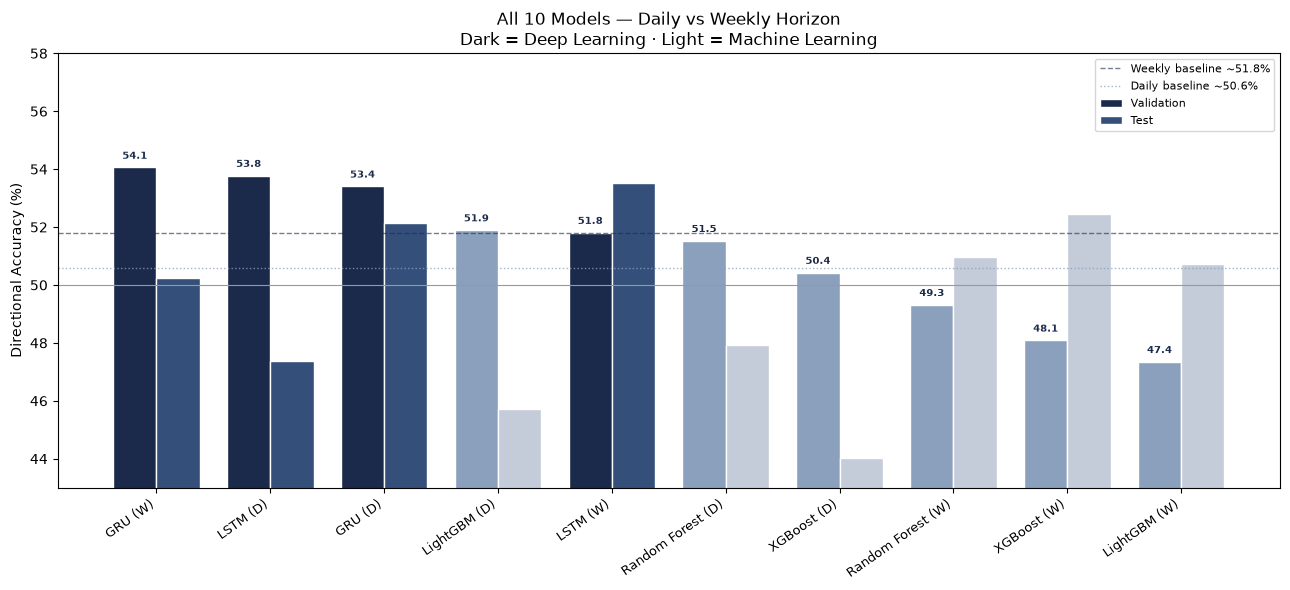

Saved 07_all_10_models.png


In [10]:
"""
Grouped bar chart: Val vs Test for all 10 models, ML vs DL color-coded.
"""
fig, ax = plt.subplots(figsize=(13, 6))

models = combined.index.tolist()
x = np.arange(len(models))
w = 0.38

# Color by model family: DL = navy, ML = steel
def is_dl(name):
    return name.startswith(("LSTM", "GRU"))
val_colors  = ["#1b2a4a" if is_dl(m) else "#8ba0bd" for m in models]
test_colors = ["#34507a" if is_dl(m) else "#c3ccd8" for m in models]

bars1 = ax.bar(x - w/2, combined["val"],  w, label="Validation", color=val_colors, edgecolor="white")
bars2 = ax.bar(x + w/2, combined["test"], w, label="Test", color=test_colors, edgecolor="white")

ax.axhline(50, color="#999999", lw=0.8, ls="-")
ax.axhline(51.8, color="#1b2a4a", lw=1, ls="--", alpha=0.6, label="Weekly baseline ~51.8%")
ax.axhline(50.6, color="#8ba0bd", lw=1, ls=":", alpha=0.8, label="Daily baseline ~50.6%")

# value labels on validation bars
for b, v in zip(bars1, combined["val"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}",
            ha="center", fontsize=7.5, fontweight="bold", color="#1b2a4a")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Directional Accuracy (%)")
ax.set_ylim(43, 58)
ax.set_title("All 10 Models — Daily vs Weekly Horizon\n"
             "Dark = Deep Learning · Light = Machine Learning", fontsize=12)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_all_10_models.png", dpi=120)
plt.show()
print("Saved 07_all_10_models.png")

In [12]:
"""
Save the fitted scaler for the prediction app.
"""
import joblib
joblib.dump(scaler, MODELS_DIR / "scaler_direction.pkl")
print("Saved scaler_direction.pkl")
print(f"Fitted on {scaler.n_features_in_} features")

Saved scaler_direction.pkl
Fitted on 31 features
